# Coastal Frontier — Exploratory Analysis

**What is in our 3,096 events?**

This notebook is the first look at the filtered UCDP dataset. The goal here is *not*
yet to test the hypothesis (southward spread of jihadist violence) — that comes later.
The goal here is simply to understand what is in the data:

- Which countries dominate the dataset?
- How are events distributed across time?
- What kinds of violence (state-based, non-state, one-sided)?
- Who are the major actors?

Until we know what "normal" looks like in this data, we cannot recognize anomaly.

In [1]:
# --- Imports and config ---
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook lives in notebooks/, but we want to import from src/
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.coastal_frontier.config import DATA_INTERIM

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print("Imports loaded. Project root:", PROJECT_ROOT)

Imports loaded. Project root: C:\dev\coastal-frontier


## Load the filtered dataset

Reading directly from the interim Parquet that the UCDP loader produced. Parquet
preserves data types — no string-to-date coercion needed.

In [2]:
df = pd.read_parquet(DATA_INTERIM / "ucdp_events_filtered.parquet")
print(f"Loaded {len(df):,} events, {len(df.columns)} columns")
print(f"Date range: {df['date_start'].min().date()} to {df['date_start'].max().date()}")
df.head(3)

Loaded 3,096 events, 27 columns
Date range: 2020-01-03 to 2026-04-29


,id,relid,year,date_start,date_end,date_prec,country,adm_1,adm_2,latitude,longitude,where_prec,priogrid_gid,side_a,side_b,dyad_name,conflict_name,type_of_violence,best,high,low,deaths_a,deaths_b,deaths_civilians,code_status,event_clarity,number_of_sources
0,503705,BEN-2023-3-15136-151,2023,2023-01-30,2023-01-31,2,Benin,Alibori department,Banikoara commune,11.339660,2.459150,3,145805,JNIM,Civilians,JNIM - Civilians,JNIM - Civilians,3,3,3,3,0,0,3,Clear,1,1
1,473958,BEN-2023-3-15136-57,2023,2023-05-01,2023-05-02,2,Benin,Atacora department,Kérou commune,11.068111,1.920931,1,145804,JNIM,Civilians,JNIM - Civilians,JNIM - Civilians,3,7,15,7,0,0,7,Clear,1,4
2,473959,BEN-2023-3-15136-59,2023,2023-05-02,2023-05-03,2,Benin,Alibori department,Banikoara commune,11.308440,2.144809,1,145805,JNIM,Civilians,JNIM - Civilians,JNIM - Civilians,3,3,3,3,0,0,3,Clear,1,2


### Column types

A quick `df.info()` confirms the schema landed correctly — dates as datetimes, fatalities as integers, lat/lon as floats.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3096 entries, 0 to 3095
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 3096 non-null   int64         
 1   relid              3096 non-null   str           
 2   year               3096 non-null   int64         
 3   date_start         3096 non-null   datetime64[us]
 4   date_end           3096 non-null   datetime64[us]
 5   date_prec          3096 non-null   int64         
 6   country            3096 non-null   str           
 7   adm_1              3095 non-null   str           
 8   adm_2              3012 non-null   str           
 9   latitude           3096 non-null   float64       
 10  longitude          3096 non-null   float64       
 11  where_prec         3096 non-null   int64         
 12  priogrid_gid       3096 non-null   int64         
 13  side_a             3096 non-null   str           
 14  side_b             

## Country distribution

Which of our seven countries carries the burden? This shapes everything that follows
— if events are concentrated in two or three countries, our spread analysis is largely
about those countries.

In [4]:
country_counts = df["country"].value_counts()
print(country_counts)
print(f"\nMost violent country: {country_counts.idxmax()} ({country_counts.max():,} events)")
print(f"Least violent country: {country_counts.idxmin()} ({country_counts.min():,} events)")
print(f"Concentration: top 3 countries hold {country_counts.head(3).sum() / country_counts.sum():.0%} of events")

country
Mali            1385
Burkina Faso    1266
Niger            329
Benin             58
Togo              40
Ghana             17
Ivory Coast        1
Name: count, dtype: int64

Most violent country: Mali (1,385 events)
Least violent country: Ivory Coast (1 events)
Concentration: top 3 countries hold 96% of events


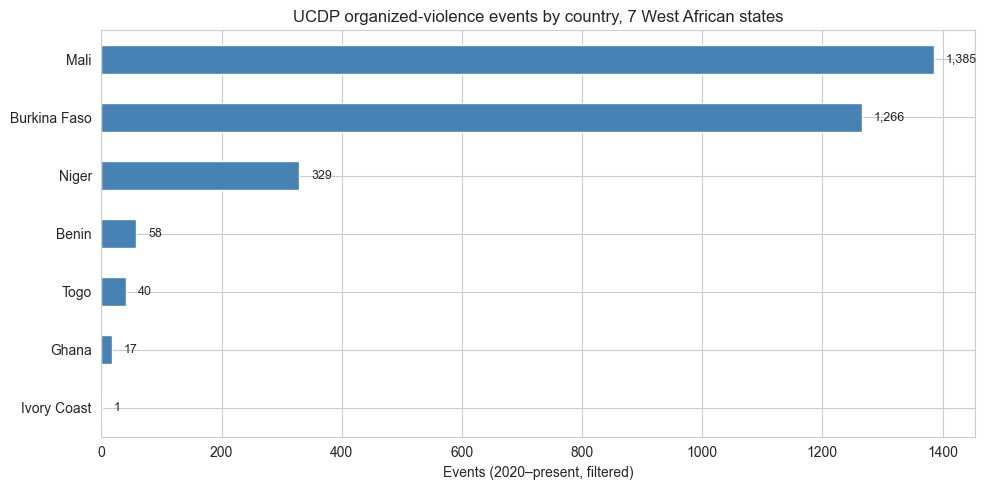

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
country_counts.sort_values().plot(kind="barh", color="steelblue", ax=ax)
ax.set_xlabel("Events (2020–present, filtered)")
ax.set_title("UCDP organized-violence events by country, 7 West African states")
ax.set_ylabel("")
for i, v in enumerate(country_counts.sort_values()):
    ax.text(v + 20, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## Temporal trend

How has violence evolved year by year, regionally and per country?

year
2020    383
2021    418
2022    592
2023    899
2024    745
2026     59
dtype: int64


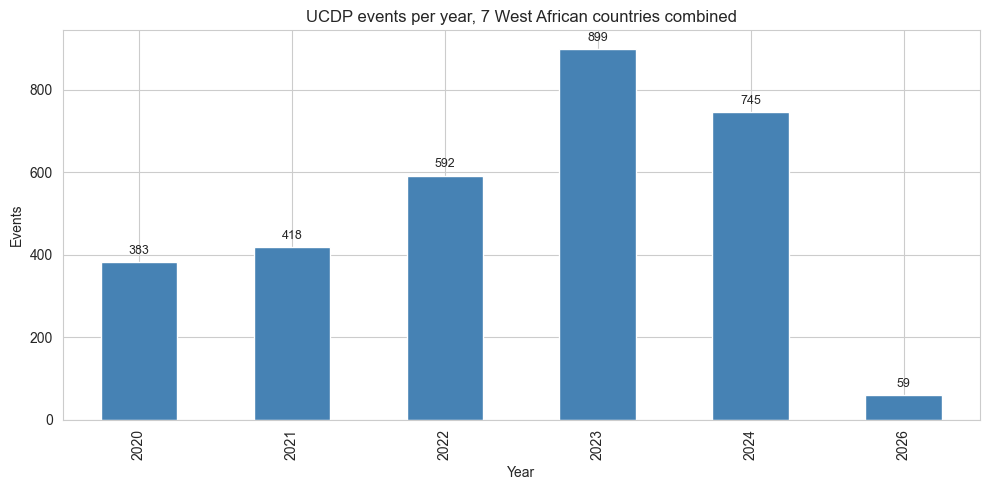

In [6]:
events_per_year = df.groupby("year").size()
print(events_per_year)

fig, ax = plt.subplots(figsize=(10, 5))
events_per_year.plot(kind="bar", color="steelblue", ax=ax)
ax.set_xlabel("Year")
ax.set_ylabel("Events")
ax.set_title("UCDP events per year, 7 West African countries combined")
for i, v in enumerate(events_per_year):
    ax.text(i, v + 20, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

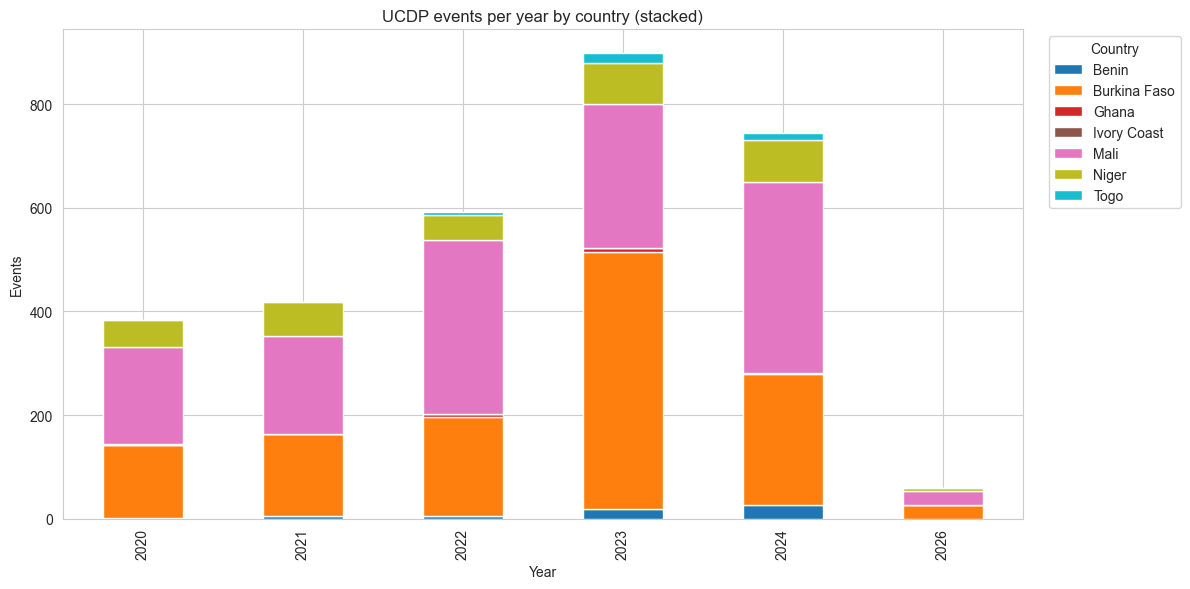

country  Benin  Burkina Faso  Ghana  Ivory Coast  Mali  Niger  Togo
year                                                               
2020         1           142      0            1   188     51     0
2021         6           158      0            0   189     65     0
2022         6           191      5            0   335     48     7
2023        18           496      9            0   278     79    19
2024        27           252      3            0   368     81    14
2026         0            27      0            0    27      5     0


In [7]:
# Country x year as stacked bars
events_by_country_year = df.groupby(["year", "country"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
events_by_country_year.plot(kind="bar", stacked=True, colormap="tab10", ax=ax)
ax.set_xlabel("Year")
ax.set_ylabel("Events")
ax.set_title("UCDP events per year by country (stacked)")
ax.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Show the raw matrix below the chart
print(events_by_country_year)

## Violence type breakdown

UCDP categorizes every event into one of three types:

- **1 = State-based** — government forces vs. an organized armed group
- **2 = Non-state** — organized group vs. another organized group (no state party)
- **3 = One-sided** — attacks against civilians by an organized actor

violence_type_label
State-based              1906
One-sided (civilians)     930
Non-state                 260
Name: count, dtype: int64

Share of fatalities ('best' estimate) by violence type:
violence_type_label
State-based              15770
One-sided (civilians)     8270
Non-state                 2347
Name: best, dtype: int64


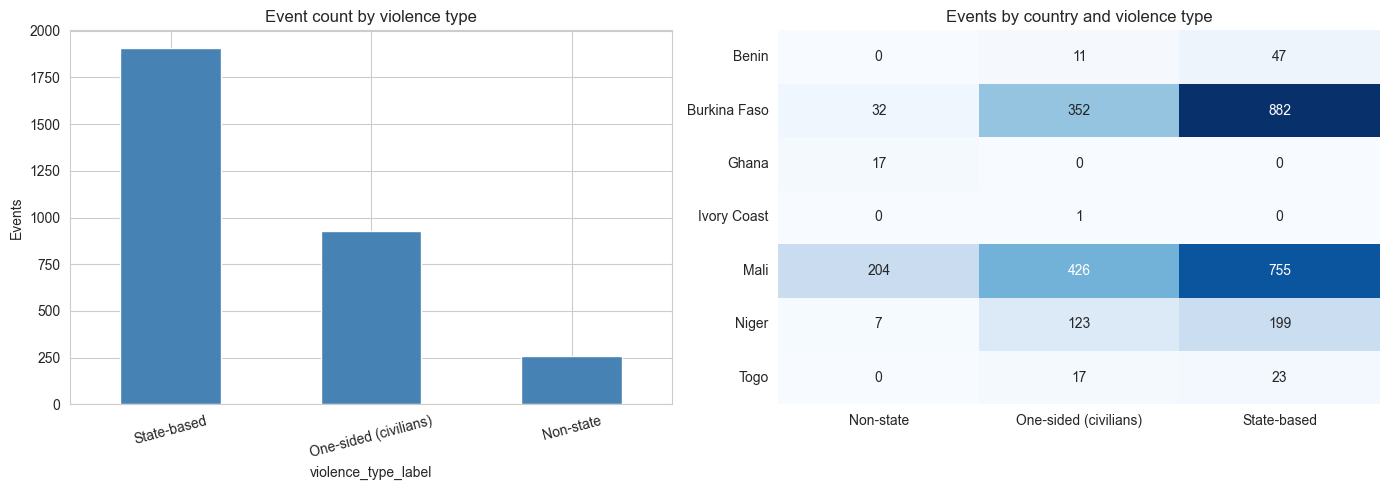

In [8]:
violence_labels = {
    1: "State-based",
    2: "Non-state",
    3: "One-sided (civilians)",
}
df["violence_type_label"] = df["type_of_violence"].map(violence_labels)

violence_counts = df["violence_type_label"].value_counts()
print(violence_counts)
print(f"\nShare of fatalities ('best' estimate) by violence type:")
print(df.groupby("violence_type_label")["best"].sum().sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

violence_counts.plot(kind="bar", color="steelblue", ax=axes[0])
axes[0].set_title("Event count by violence type")
axes[0].set_ylabel("Events")
axes[0].tick_params(axis="x", rotation=15)

# Country x violence type heatmap
ct = pd.crosstab(df["country"], df["violence_type_label"])
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=axes[1], cbar=False)
axes[1].set_title("Events by country and violence type")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Top actors (dyads)

A "dyad" is a pair of conflicting parties. The most active dyads tell us who the
data is really *about*.

dyad_name
Government of Burkina Faso - JNIM                                      733
Government of Mali - JNIM                                              612
JNIM - Civilians                                                       325
IS - Civilians                                                         276
Government of Burkina Faso - IS                                        149
Government of Niger - IS                                               143
Government of Mali - Civilians                                         107
Government of Mali - IS                                                105
Government of Mali, Government of Russia (Soviet Union) - Civilians     90
IS - JNIM                                                               83
Government of Burkina Faso - Civilians                                  71
Dozos (Mali) - JNIM                                                     61
Dan na Ambassagou - JNIM                                                51
Government of B

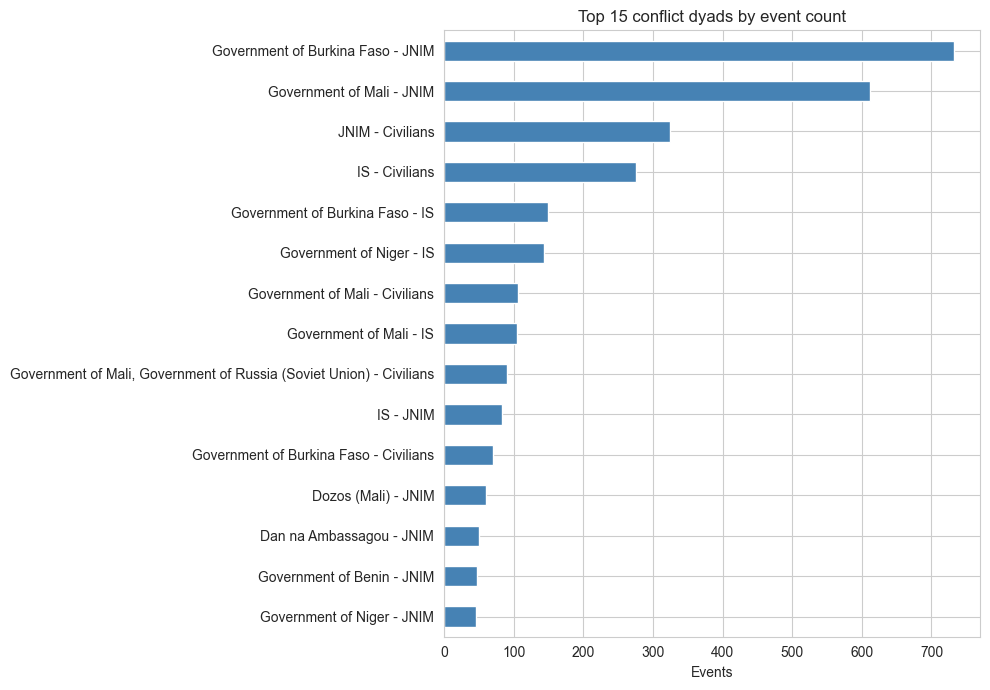

In [9]:
top_dyads = df["dyad_name"].value_counts().head(15)
print(top_dyads)

fig, ax = plt.subplots(figsize=(10, 7))
top_dyads.sort_values().plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("Top 15 conflict dyads by event count")
ax.set_xlabel("Events")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Country distribution
country
Mali            1385
Burkina Faso    1266
Niger            329
Benin             58
Togo              40
Ghana             17
Ivory Coast        1

Temporal trend
year
2020    383
2021    418
2022    592
2023    899
2024    745
2026     59

Violence type breakdown
country  Benin  Burkina Faso  Ghana  Ivory Coast  Mali  Niger  Togo
year                                                               
2020         1           142      0            1   188     51     0
2021         6           158      0            0   189     65     0
2022         6           191      5            0   335     48     7
2023        18           496      9            0   278     79    19
2024        27           252      3            0   368     81    14
2026         0            27      0            0    27      5     0
UCDP categorizes every event into one of three types:

1 = State-based — government forces vs. an organized armed group
2 = Non-state — organized group vs. another organized group (no state party)
3 = One-sided — attacks against civilians by an organized actor

violence_type_label
State-based              1906
One-sided (civilians)     930
Non-state                 260
Name: count, dtype: int64

Share of fatalities ('best' estimate) by violence type:
violence_type_label
State-based              15770
One-sided (civilians)     8270
Non-state                 2347

Top actors (dyads)

dyad_name
Government of Burkina Faso - JNIM                                      733
Government of Mali - JNIM                                              612
JNIM - Civilians                                                       325
IS - Civilians                                                         276
Government of Burkina Faso - IS                                        149
Government of Niger - IS                                               143
Government of Mali - Civilians                                         107
Government of Mali - IS                                                105
Government of Mali, Government of Russia (Soviet Union) - Civilians     90
IS - JNIM                                                               83
Government of Burkina Faso - Civilians                                  71
Dozos (Mali) - JNIM                                                     61
Dan na Ambassagou - JNIM                                                51
Government of Benin - JNIM                                              47
Government of Niger - JNIM                                              46

three observations (just retype them in the chat)
The southward spread is visible. Togo had zero UCDP events in 2020–2021; 19 by 2023. Benin went from 1 to 18 in the same window. The hypothesis is supported in the raw counts even before any spatial analysis — but I should check whether the rises are concentrated near the Burkina/Niger borders.

Burkina Faso's 2023 spike (191 → 496) is the most dramatic year-on-year shift in the region. It coincides with the post-second-coup period and the arrival of Wagner / Africa Corps. The next notebook needs to look at whether this was a displacement of violence from Mali or genuinely new violence.

UCDP coded Wagner-Mali joint operations against civilians as a distinct dyad with 90 events. This is a publishable finding by itself and a methodological caveat for the broader analysis — civilian-targeting metrics in Mali are partly capturing Russian-backed operations, not just jihadist attacks.

The 2025 year is missing from the data. Either UCDP's release cycle dropped it or our filter excluded it. Worth investigating before we trust 2026 numbers.